In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import json
import pandas as pd
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
Cards = pd.read_csv("./data/cards_data.csv")
Transactions = pd.read_csv("./data/transactions_data.csv")
Users = pd.read_csv("./data/users_data.csv")

In [3]:
Cards['credit_limit'] = Cards['credit_limit'].replace('[\$,]', '', regex=True).astype(float)
Users['yearly_income'] = Users['yearly_income'].replace('[\$,]', '', regex=True).astype(float)
Users['total_debt'] = Users['total_debt'].replace('[\$,]', '', regex=True).astype(float)
Users['per_capita_income'] = Users['per_capita_income'].replace('[\$,]', '', regex=True).astype(float)
Transactions['amount'] = Transactions['amount'].replace('[\$,]', '', regex=True).astype(float)

# 合併三表
Trans_merge = pd.DataFrame()
Trans_merge = Transactions.merge(Cards, left_on="card_id", right_on="id", suffixes=("_txn","_card"))
Trans_merge = Trans_merge.merge(Users, left_on="client_id_txn", right_on="id", suffixes=("","_user"))

In [4]:
Trans_merge['date'] = pd.to_datetime(Trans_merge['date'])

## 每小時交易量
Trans_merge['hour'] = Trans_merge['date'].dt.floor('H')

hourly_volume = (
    Trans_merge
    .groupby(['client_id_txn', 'hour'])['amount']
    .sum()
    .reset_index()
    .rename(columns={'amount': 'hourly_transaction_volume'})
)

if 'hourly_transaction_volume' in Trans_merge.columns:
    Trans_merge = Trans_merge.drop(columns=['hourly_transaction_volume'])
    
Trans_merge = Trans_merge.merge(
    hourly_volume,
    on=['client_id_txn', 'hour'],
    how='left'
)

In [5]:
drop_cols = [
    'address',
    'zip',
    'card_id', 'id',
    'birth_year', 'birth_month', 'current_age', 'retirement_age',
    'card_number', 'expires', 'cvv',
    'acct_open_date', 'year_pin_last_changed', 'num_cards_issued',
    'latitude', 'longitude',
    'mcc', 'errors',
]

Trans_merge_clean = Trans_merge.drop(columns=drop_cols)

In [6]:
with open('./data/train_fraud_labels.json', 'r') as f:
    fraud_data = json.load(f)

fraud_dict = fraud_data['target']

fraud_dict = {int(k): v for k, v in fraud_dict.items()}

Trans_merge_clean['id_txn'] = Trans_merge_clean['id_txn'].astype(int)

Trans_merge_clean['is_fraud'] = Trans_merge_clean['id_txn'].map(fraud_dict)
Trans_merge_clean = Trans_merge_clean[Trans_merge_clean['is_fraud'].notna()].copy()
Trans_merge_clean['is_fraud'] = Trans_merge_clean['is_fraud'].map({'Yes': 1, 'No': 0})

In [7]:
for item in Trans_merge_clean:
    print(item)

id_txn
date
client_id_txn
amount
use_chip
merchant_id
merchant_city
merchant_state
id_card
client_id_card
card_brand
card_type
has_chip
credit_limit
card_on_dark_web
gender
per_capita_income
yearly_income
total_debt
credit_score
num_credit_cards
hour
hourly_transaction_volume
is_fraud


In [8]:
print(Trans_merge_clean.head())
fraud_counts = Trans_merge_clean['is_fraud'].value_counts()


print(Trans_merge_clean['is_fraud'].value_counts())

    id_txn                date  client_id_txn  amount           use_chip  \
0  7475327 2010-01-01 00:01:00           1556  -77.00  Swipe Transaction   
1  7475328 2010-01-01 00:02:00            561   14.57  Swipe Transaction   
2  7475329 2010-01-01 00:02:00           1129   80.00  Swipe Transaction   
4  7475332 2010-01-01 00:06:00            848   46.41  Swipe Transaction   
5  7475333 2010-01-01 00:07:00           1807    4.81  Swipe Transaction   

   merchant_id merchant_city merchant_state  id_card  client_id_card  ...  \
0        59935        Beulah             ND     2972            1556  ...   
1        67570    Bettendorf             IA     4575             561  ...   
2        27092         Vista             CA      102            1129  ...   
4        13051       Harwood             MD     3915             848  ...   
5        20519         Bronx             NY      165            1807  ...   

  card_on_dark_web  gender per_capita_income  yearly_income total_debt  \
0     

In [9]:
# 分出訓練集與測試集
X = Trans_merge_clean.drop('is_fraud', axis=1)
y = Trans_merge_clean['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=34, 
    stratify=y  
)

# 預處理清潔資料
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numerical_features = ['amount', 'credit_limit', 'per_capita_income', 
                      'yearly_income', 'total_debt', 'credit_score', 
                      'num_credit_cards', 'hourly_transaction_volume']

categorical_features = ['use_chip', 'card_brand', 'card_type', 'has_chip', 
                        'card_on_dark_web', 'gender']

features_to_keep = numerical_features + categorical_features
X_train_processed = X_train[features_to_keep].copy()
X_test_processed = X_test[features_to_keep].copy()

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

X_train_final = preprocessor.fit_transform(X_train_processed)
X_test_final = preprocessor.transform(X_test_processed)

In [10]:
print(f"All data: {len(Trans_merge_clean)}")
print("-" * 30)
print(f"All training data (70%): {len(X_train_final)}")
print(y_train.value_counts().rename_axis('is_fraud').to_frame('count').to_string())
print("-" * 30)
print(f"All testing data (30%): {len(X_test_final)}")
print(y_test.value_counts().rename_axis('is_fraud').to_frame('count').to_string())
print("-" * 30)

All data: 8914963
------------------------------
All training data (70%): 6240474
            count
is_fraud         
0         6231142
1            9332
------------------------------
All testing data (30%): 2674489
            count
is_fraud         
0         2670489
1            4000
------------------------------


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, accuracy_score

# 建立 Logistic regression 模型
logreg_benchmark = LogisticRegression(
    solver='liblinear', 
    class_weight='balanced', 
    random_state=34, 
    max_iter=1000
)

logreg_benchmark.fit(X_train_final, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,34
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
y_pred_benchmark = logreg_benchmark.predict(X_test_final)

conf_matrix = confusion_matrix(y_test, y_pred_benchmark)
print("\n[Confusion Matrix]")
print(f"   TN  FP\n   FN  TP\n{conf_matrix}")

acc = accuracy_score(y_test, y_pred_benchmark)
prec = precision_score(y_test, y_pred_benchmark)
rec = recall_score(y_test, y_pred_benchmark)
f1 = f1_score(y_test, y_pred_benchmark)

print(f"\n總體準確率 (Accuracy): {acc:.4f}")
print(f"詐欺召回率 (Recall, 類別 1): {rec:.4f}")
print(f"詐欺精確率 (Precision, 類別 1): {prec:.4f}")
print(f"F1-Score (類別 1): {f1:.4f}")


[Confusion Matrix]
   TN  FP
   FN  TP
[[2276372  394117]
 [   1141    2859]]

總體準確率 (Accuracy): 0.8522
詐欺召回率 (Recall, 類別 1): 0.7147
詐欺精確率 (Precision, 類別 1): 0.0072
F1-Score (類別 1): 0.0143


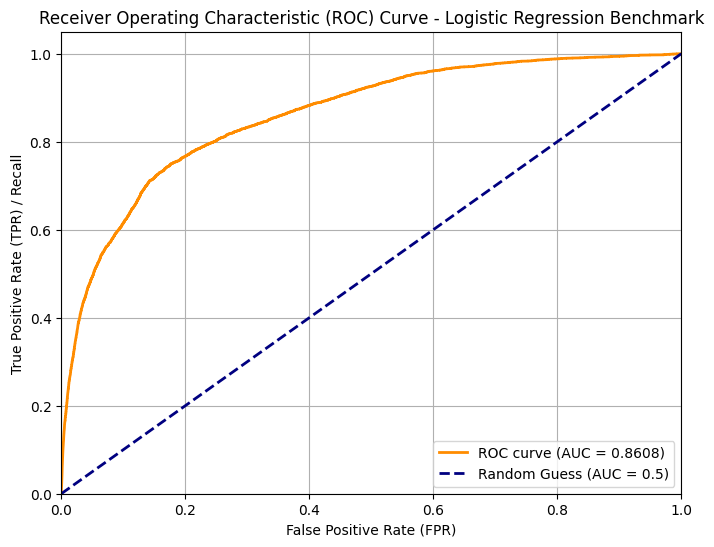


✅ ROC 曲線繪製完成！
基準模型 ROC AUC Score: 0.8608


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_benchmark = logreg_benchmark.predict_proba(X_test_final)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_benchmark)

roc_auc = roc_auc_score(y_test, y_prob_benchmark)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Guess (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression Benchmark')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"\n✅ ROC 曲線繪製完成！")
print(f"基準模型 ROC AUC Score: {roc_auc:.4f}")

In [14]:
# 找出一些比較重要的特徵
feature_names = list(numerical_features)
onehot_cols = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
feature_names.extend(onehot_cols)

coefficients = logreg_benchmark.coef_[0]

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
top_features = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

print(top_features[['Feature', 'Coefficient']].to_string(index=False))

                    Feature  Coefficient
use_chip_Online Transaction     1.811224
 use_chip_Swipe Transaction    -1.646935
                has_chip_NO     0.468736
  hourly_transaction_volume     0.463701
               has_chip_YES    -0.434232
           num_credit_cards     0.188478
        card_brand_Discover     0.142094
               credit_limit    -0.132673
  use_chip_Chip Transaction    -0.129784
  card_type_Debit (Prepaid)     0.123520
            card_type_Debit    -0.123226
              yearly_income    -0.106681
            card_brand_Amex    -0.083349
                     amount    -0.046300
              gender_Female     0.041452
        card_on_dark_web_No     0.034504
           card_type_Credit     0.034210
                 total_debt     0.029338
          per_capita_income     0.022144
      card_brand_Mastercard    -0.013410


看起來比較有關聯的
## 數值
### hourly_transaction_volum -> 越高越好
### 

## 類別
### use_chip
- Online -> 高機率
- Swipe -> 低機率
### has_chip
- Yes -> 低機率
- No -> 高機率

In [15]:
# num_cols = [
#     'amount', 'hourly_transaction_volume', 'yearly_income',
#     'credit_limit', 'total_debt', 'num_credit_cards'
# ]

# sns.pairplot(
#     Trans_merge_clean[num_cols + ['is_fraud']],
#     hue='is_fraud',
#     corner=True,
#     plot_kws={'alpha':0.5}
# )
# plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix, accuracy_score

## 新增交互項
Trans_merge_clean['chip_combo'] = Trans_merge_clean['use_chip'] + "_" + Trans_merge_clean['has_chip']
Trans_merge_clean['amount_x_volume'] = Trans_merge_clean['amount'] * Trans_merge_clean['hourly_transaction_volume']
Trans_merge_clean['chip_x_cardtype'] = Trans_merge_clean['use_chip'] + "_" + Trans_merge_clean['card_type']
Trans_merge_clean['darkweb_x_brand'] = Trans_merge_clean['card_on_dark_web'] + "_" + Trans_merge_clean['card_brand']

X = Trans_merge_clean.drop('is_fraud', axis=1)
y = Trans_merge_clean['is_fraud']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=34, 
    stratify=y  
)

numerical_features = [
    'amount', 'hourly_transaction_volume', 'yearly_income',
    'credit_limit', 'total_debt', 'num_credit_cards',
    'amount_x_volume'
]

categorical_features = [
    'use_chip', 'has_chip', 'card_type', 'card_brand',
    'card_on_dark_web', 'chip_combo',
    'chip_x_cardtype', 'darkweb_x_brand'
]

features_to_keep = numerical_features + categorical_features
X_train_processed = X_train_new[features_to_keep].copy()
X_test_processed = X_test_new[features_to_keep].copy()

for col in numerical_features:
    X_train_processed[col] = pd.to_numeric(X_train_processed[col], errors='coerce')
    X_test_processed[col] = pd.to_numeric(X_test_processed[col], errors='coerce')

def log_transform(X):
    if isinstance(X, pd.DataFrame):
        X_abs = X.abs()
        return np.log1p(X_abs)
    else:
        return np.log1p(np.abs(X))

log_features = ['amount', 'yearly_income', 'total_debt']
standard_features = [f for f in numerical_features if f not in log_features]

# 1. Log 轉換 -> 填補 -> 標準化
log_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(log_transform, validate=False)),
    ('scaler', StandardScaler())
])

# 2. 數值填補 -> 標準化
standard_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. 類別填補
categorical_transformer_new = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 結合所有處理步驟
preprocessor_tuned = ColumnTransformer(
    transformers=[
        ('log_num', log_transformer, log_features),
        ('std_num', standard_transformer, standard_features),
        ('cat', categorical_transformer_new, categorical_features)
    ],
    remainder='drop'
)

X_train_tuned = preprocessor_tuned.fit_transform(X_train_processed)
X_test_tuned = preprocessor_tuned.transform(X_test_processed)

print(f"{X_train_tuned.shape}")

logreg_tuned = LogisticRegression(
    solver='saga', 
    class_weight='balanced', 
    penalty='l2', 
    random_state=34, 
    max_iter=5000
)

logreg_tuned.fit(X_train_tuned, y_train)
y_pred_tuned = logreg_tuned.predict(X_test_tuned)
y_prob_tuned = logreg_tuned.predict_proba(X_test_tuned)[:, 1]

acc_tuned = accuracy_score(y_test_new, y_pred_tuned)
rec_tuned = recall_score(y_test_new, y_pred_tuned)
f1_tuned = f1_score(y_test_new, y_pred_tuned)
auc_tuned = roc_auc_score(y_test_new, y_prob_tuned)

# 顯示混淆矩陣
conf_matrix_tuned = confusion_matrix(y_test_new, y_pred_tuned)


print("\n[Confusion Matrix]")
print(f"   TN  FP\n   FN  TP\n{conf_matrix_tuned}")

print(f"總體準確率 (Accuracy): {acc_tuned:.4f}")
print(f"詐欺召回率 (Recall, 類別 1): {rec_tuned:.4f}")
print(f"F1-Score (類別 1): {f1_tuned:.4f}")
print(f"ROC AUC Score: {auc_tuned:.4f}")

(6240474, 38)

[Confusion Matrix]
   TN  FP
   FN  TP
[[2248817  421672]
 [   1070    2930]]
總體準確率 (Accuracy): 0.8419
詐欺召回率 (Recall, 類別 1): 0.7325
F1-Score (類別 1): 0.0137
ROC AUC Score: 0.8627


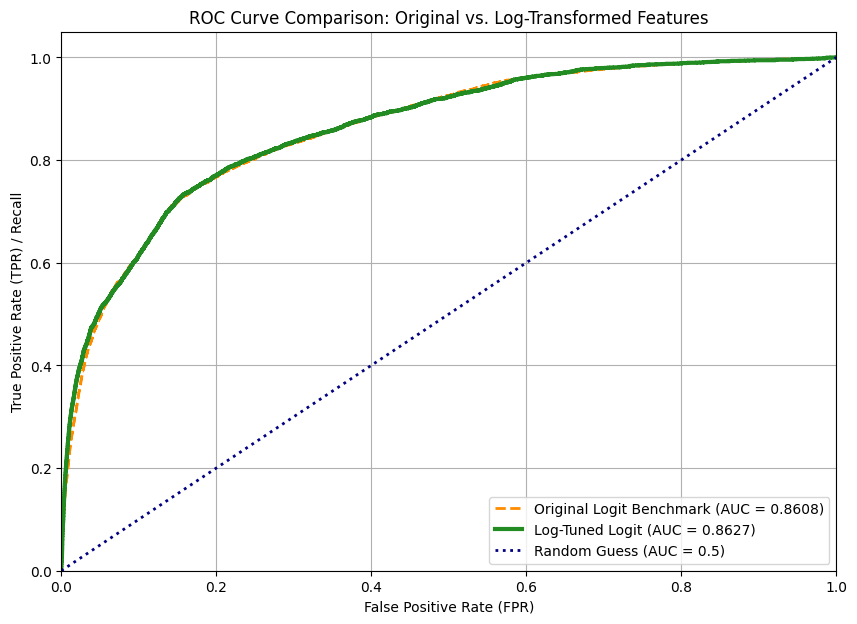

原始 Logit AUC: 0.8608
Log 轉換 Logit AUC: 0.8627


In [17]:
y_prob_benchmark = logreg_benchmark.predict_proba(X_test_final)[:, 1]
fpr_benchmark, tpr_benchmark, _ = roc_curve(y_test, y_prob_benchmark)
auc_benchmark = roc_auc_score(y_test, y_prob_benchmark)

y_prob_tuned = logreg_tuned.predict_proba(X_test_tuned)[:, 1]
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)
auc_tuned = roc_auc_score(y_test, y_prob_tuned)

plt.figure(figsize=(10, 7))
plt.plot(fpr_benchmark, tpr_benchmark, color='darkorange', lw=2, 
         label=f'Original Logit Benchmark (AUC = {auc_benchmark:.4f})', 
         linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, color='forestgreen', lw=3, 
         label=f'Log-Tuned Logit (AUC = {auc_tuned:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle=':', 
         label='Random Guess (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('ROC Curve Comparison: Original vs. Log-Transformed Features')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"原始 Logit AUC: {auc_benchmark:.4f}")
print(f"Log 轉換 Logit AUC: {auc_tuned:.4f}")

In [18]:
from sklearn.preprocessing import RobustScaler
from geopy.distance import geodesic
import numpy as np
import pandas as pd

df = Trans_merge.copy()

# 指定群組欄位
GROUP_BY_CLIENT = ['client_id_txn']

# 確保日期欄位為 datetime 格式
df['date'] = pd.to_datetime(df['date'])

# 比率 Ratio
## 1. 交易金額佔信用額度的比率 (Txn_Amount / Credit_Limit)
df['Risk_Amount_to_Limit'] = np.where(
    df['credit_limit'].gt(0),
    df['amount'] / df['credit_limit'],
    np.nan
)

## 2. 總負債佔年收入的比率 (Total_Debt / Yearly_Income)
df['Risk_Debt_to_Income'] = np.where(
    df['yearly_income'].gt(0),
    df['total_debt'] / df['yearly_income'],
    np.nan
)

## 3. 信用額度使用壓力 (Total_Debt / Credit_Limit)
df['Risk_Debt_to_Limit'] = np.where(
    df['credit_limit'].gt(0),
    df['total_debt'] / df['credit_limit'],
    np.nan
)

## 4. 小時交易量佔信用評分的比率 (Hourly_Volume / Credit_Score)
if 'hourly_transaction_volume' in df.columns:
    df['Risk_Volume_to_Score'] = np.where(
        df['credit_score'].gt(0),
        df['hourly_transaction_volume'] / df['credit_score'],
        np.nan
    )
else:
    df['Risk_Volume_to_Score'] = np.nan

## 5. 年收入佔當地人均收入比率 (Yearly_Income / Per_Capita_Income)
df['Risk_Income_vs_Local'] = np.where(
    df['per_capita_income'].gt(0),
    df['yearly_income'] / df['per_capita_income'],
    np.nan
)

## 6. 信用評分正規化 (Robust Standardization is recommended by the paper) [4]
scaler = RobustScaler()
df['credit_score_scaled'] = scaler.fit_transform(df[['credit_score']])

# 7. 交易頻率比率 (Transaction Velocity)
for days in [4, 7]:
    col_name = f'Txn_Count_{days}D'
    df[col_name] = (
        df.groupby(GROUP_BY_CLIENT, group_keys=False)
        .apply(lambda g: g.assign(
            **{
                col_name: g.sort_values('date')
                .set_index('date')['id_txn']
                .rolling(f'{days}D', closed='left')
                .count()
                .reset_index(drop=True)
            }
        ))[col_name]
    )

df['Ratio_Txn_Count_vs_7D_Avg_4D'] = np.where(
    df['Txn_Count_7D'].gt(0),
    df['Txn_Count_4D'] / df['Txn_Count_7D'],
    np.nan
)

# 8. 金額偏差比率 (Amount Deviation Ratios)
for days in [6, 7]:
    mean_col = f'Amount_Mean_{days}D'
    std_col = f'Amount_Std_{days}D'

    df = df.groupby(GROUP_BY_CLIENT, group_keys=False).apply(
        lambda g: g.assign(
            **{
                mean_col: g.sort_values('date')
                .set_index('date')['amount']
                .rolling(f'{days}D', closed='left')
                .mean()
                .reset_index(drop=True),
                std_col: g.sort_values('date')
                .set_index('date')['amount']
                .rolling(f'{days}D', closed='left')
                .std()
                .reset_index(drop=True)
            }
        )
    )

    df[f'Ratio_Amount_vs_Mean_{days}D'] = np.where(
        df[mean_col].gt(0),
        df['amount'] / df[mean_col],
        np.nan
    )

    df[f'Z_Score_Amount_{days}D'] = np.where(
        df[std_col].gt(0),
        (df['amount'] - df[mean_col]) / df[std_col],
        np.nan
    )
    
# Boolean
## 1. 是否為線上交易 (One-Hot Encoding of key transaction type)
df['is_chip_txn'] = (df['use_chip'] == 'Chip Transaction').astype(int)
df['is_swipe_txn'] = (df['use_chip'] == 'Swipe Transaction').astype(int)
df['is_online_txn'] = (df['use_chip'] == 'Online').astype(int)

## 2. 卡片是否已在暗網 (Binary/Boolean encoding)
df['card_on_dark_web_encoded'] = (df['card_on_dark_web'] == 'Yes').astype(int)
df['is_credit_card'] = (df['card_type'] == 'Credit').astype(int)

In [33]:
df_clean['id_txn'] = df_clean['id_txn'].astype(int)

df_clean['is_fraud'] = df_clean['id_txn'].map(fraud_dict)
df_clean = df_clean[df_clean['is_fraud'].notna()].copy()
df_clean['is_fraud'] = df_clean['is_fraud'].map({'Yes': 1, 'No': 0})

new_cols = [c for c in df.columns if c not in Trans_merge]

print(new_cols)
print("\n")
print(df[new_cols].head())

['Risk_Amount_to_Limit', 'Risk_Debt_to_Income', 'Risk_Debt_to_Limit', 'Risk_Volume_to_Score', 'Risk_Income_vs_Local', 'credit_score_scaled', 'Txn_Count_4D', 'Txn_Count_7D', 'Ratio_Txn_Count_vs_7D_Avg_4D', 'Amount_Mean_6D', 'Amount_Std_6D', 'Ratio_Amount_vs_Mean_6D', 'Z_Score_Amount_6D', 'Amount_Mean_7D', 'Amount_Std_7D', 'Ratio_Amount_vs_Mean_7D', 'Z_Score_Amount_7D', 'is_chip_txn', 'is_swipe_txn', 'is_online_txn', 'card_on_dark_web_encoded', 'is_credit_card', 'is_fraud']


   Risk_Amount_to_Limit  Risk_Debt_to_Income  Risk_Debt_to_Limit  \
0             -1.400000             2.281687         2002.781818   
1              0.001601             3.042873           12.322967   
2              0.005405             1.060698            2.468585   
4              0.002428             1.406951            5.032282   
5              0.054045             1.894036         1108.011236   

   Risk_Volume_to_Score  Risk_Income_vs_Local  credit_score_scaled  \
0              0.053554              2.038

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd

original_cols = set(Trans_merge.columns)
new_cols = [c for c in df.columns if c not in original_cols and c != 'is_fraud']

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=34,
    stratify=y
)

numerical_features = [col for col in new_cols if df[col].dtype != 'object']
categorical_features = [col for col in new_cols if df[col].dtype == 'object']

log_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(lambda x: np.log1p(np.abs(x)), validate=False)),
    ('scaler', RobustScaler())
])

standard_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_log', log_transformer, numerical_features),
        ('num_std', standard_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='saga',
        class_weight='balanced',
        penalty='l2',
        random_state=34,
        max_iter=5000
    ))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n[Confusion Matrix]")
print(f"   TN  FP\n   FN  TP\n{conf_matrix}")
print(f"\nAccuracy: {acc:.4f}")
print(f"Recall:   {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC:  {auc:.4f}")
